In [2]:
from astropy.io import fits
import numpy as np
from scipy import stats
#1
hdulist = fits.open('m101.fits')
hdulist.info()

#2
hdr = hdulist[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
    
dat = hdulist[0].data
print("This data structure is a:", type(dat))
print("Its shape should be (NAXIS2, NAXIS1):", (hdr['NAXIS2'], hdr['NAXIS1']) == dat.shape)

print("\nMay share memory:", np.may_share_memory(dat,hdulist[0].data))
print("Min. and max. data values:", dat.min(), dat.max())
print("Standard deviation is:", dat.std())
print("Median is:", np.median(dat))
print("Mode is:", stats.mode(dat))


Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
This data structure is a: <class 'numpy.ndarray'>
Its shape should be (NAXIS2, NAXIS1): True

May share memory: True
Min. and max. data values: 1507 15752
Standard deviation is: 1848.2526085366376
Median is: 4102.0
Mode is: ModeResult(mode=array([3672, 3672, 3347, 3347, 3264, 3264, 3326, 3326, 3551, 3551, 3394,
       3218, 3529, 3523, 3697, 3697, 3584, 3324, 3326, 3758, 3586, 3498,
       3412, 3498, 3456, 3513, 3456, 3789, 3529, 3529, 3356, 3456, 3789,
       3789, 3848, 3551, 3464, 3464, 3810, 3464, 3377, 3109, 3724, 3724,
       3377, 3377, 3377, 3724, 3315, 3930, 3377, 3709, 3622, 3375, 3610,
       3599, 3475, 3579, 3579, 3406, 3492, 3492,

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

List of first 5 headers: ['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2'] 

16
(530, 530) 

>i2
Min is  1507
MAx is  15752
Mean is : 4795.924268422927
Standard deviation is : 1848.2526085366376
Median is  4102.0
Mode is  3551
RA---TAN


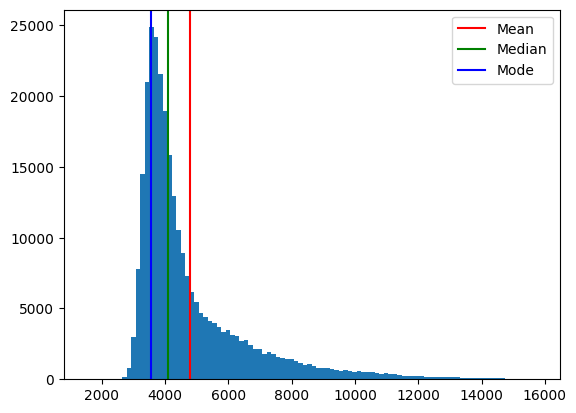

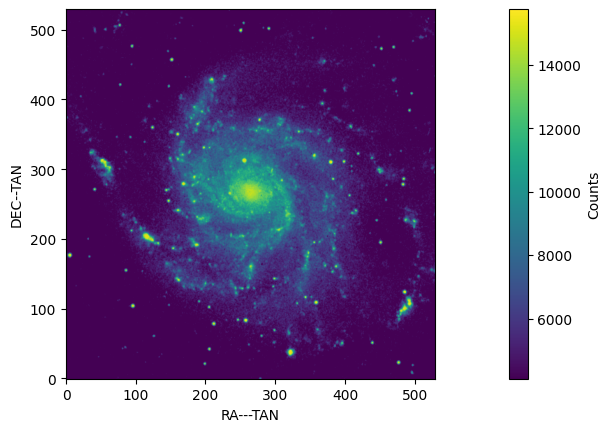

In [36]:
#Question 6.1
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable

#2
fits.info('m101.fits')
hdul = fits.open('m101.fits')
header = hdul[0].header

#3
print("\nList of first 5 headers:" ,list(header.keys())[:5] ,"\n")
print(header['BITPIX'])

#4
dat = hdul[0].data
print(dat.shape,'\n')
print(dat.dtype) #>i2 means greater than 2 bytes = 16 bits

#5
dat_flat = dat.flatten()
print("Min is " ,np.min(dat_flat))
print("MAx is " ,np.max(dat_flat))
print("Mean is :" ,np.mean(dat_flat))
print("Standard deviation is :",np.std(dat_flat))
print("Median is ",np.median(dat_flat))
print("Mode is " ,stats.mode(dat_flat, keepdims=True).mode[0])

#6
fig1, ax1 = plt.subplots()
ax1.hist(dat_flat, bins=100)
ax1.axvline(np.mean(dat_flat), color='r', label='Mean')
ax1.axvline(np.median(dat_flat), color='g', label='Median')
ax1.axvline(stats.mode(dat_flat, keepdims=True).mode[0], color='b', label='Mode')
ax1.legend()

#7
dat_float = np.asarray(dat, dtype=float)
fig2, ax2 = plt.subplots()
im = ax2.imshow(dat_float, vmin=np.median(dat_float), origin='lower')

print(header.get('CTYPE1'))
ax2.set_xlabel(header.get('CTYPE1'))
ax2.set_ylabel(header.get('CTYPE2'))

divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%")
cbar = fig2.colorbar(im, cax=cax)
cbar.set_label('Counts')
plt.show()

#8
header['BUNIT'] = 'Counts'
hdu_float = fits.PrimaryHDU(data=dat_float, header=header)
hdul.close()

In [5]:
#Question 6.3
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

hdul = fits.open('m101.fits')
data = hdul[0].data

noise_slice = data[510:530, 5:25]

rms = np.sqrt(np.mean(noise_slice**2))#squaring the pixel values first
mean = np.mean(noise_slice)
std_dev = np.std(noise_slice) #subtracting mean from each pixel before squaring

print(f"Mean: {mean}")
print(f"RMS: {rms}")
print(f"Standard Deviation: {std_dev}")

hdul.close()

Mean: 3544.085
RMS: 38.492596690792375
Standard Deviation: 297.33508500511675


In [3]:
#Question 6.5
import numpy as np
from astropy.io import fits

data0 = fits.getdata('noisemap0.fits')
data1 = fits.getdata('noisemap1.fits')
data2 = fits.getdata('noisemap2.fits')

std0 = np.std(data0)
std1 = np.std(data1)
std2 = np.std(data2)

stacked_images = np.stack((data0, data1, data2), axis=0)

mean_image = np.mean(stacked_images, axis=0)

std_mean_image = np.std(mean_image)

stds = np.array([std0, std1, std2])
N = len(stds)
theoretical_std = (1 / N) * np.sqrt(np.sum(stds**2))

print(f"Standard Deviation of Mean Image: {std_mean_image}")
print(f"Theoretical Standard Deviation: {theoretical_std}")
print(f"Diff is: {abs(std_mean_image - theoretical_std)}")

Standard Deviation of Mean Image: 5.773191380233297
Theoretical Standard Deviation: 5.770294583366139
Diff is: 0.002896796867157825


In [3]:
#Question 6.6
import numpy as np
from astropy.io import fits
from astropy.table import Table

hdul = fits.open('APOGEE_stars.fits')
t = Table(hdul[1].data)

condition = (
    (t['STARFLAG'] == 0) &
    (t['ASPCAPFLAG'] == 0) &
    (t['SNR'] > 10) &
    ((t['GAIAEDR3_PARALLAX'] / t['GAIAEDR3_PARALLAX_ERROR']) > 5) &
    (~np.isnan(t['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(t['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

t['DATAFLAG'] = np.where(condition, 1, 0)

M_G = np.full(len(t), -1.0)
valid = t['DATAFLAG'] == 1
m_G_valid = t['GAIAEDR3_PHOT_G_MEAN_MAG'][valid]
parallax_valid = t['GAIAEDR3_PARALLAX'][valid]

M_G[valid] = m_G_valid + 5 * np.log10(parallax_valid / 1000) + 5
t['ABSOLUTE_MAGNITUDE'] = M_G

t.write('APOGEE_update.fits', overwrite=True)

fits.info('APOGEE_update.fits')
updated_table = Table.read('APOGEE_update.fits')
print(updated_table)
print("\nColumn Names:")
print(updated_table.colnames)

Filename: APOGEE_update.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     28   733901R x 10C   [E, E, E, E, E, K, K, E, K, D]   
GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG ABSOLUTE_MAGNITUDE
----------------- ----------------------- ... -------- ------------------
               --                      -- ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1 2.7881622314453125
      -0.02394128               0.0450072 ...        0               -1.0
        1.3863556               0.0175672 ...        1 2.9852724075317383
              ...                     ... ...      ...                ...
         4.132398         

the maximum value in column phot_g_mean_flux is : {42489404.0}
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


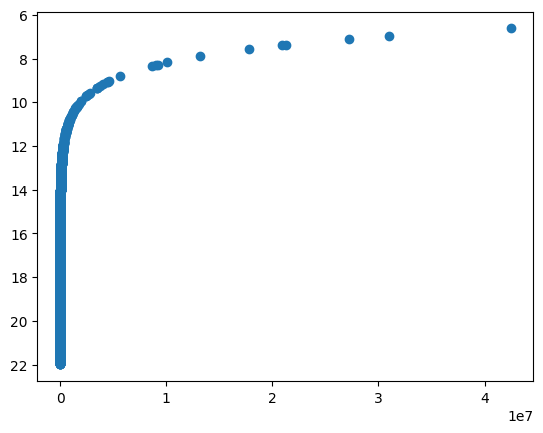

25.68840037029544


In [4]:
#Question 6.7
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#part 1
df = pd.read_csv('gaiaTestData.csv')

#part 2
max_flux = df['phot_g_mean_flux'].max()
print("the maximum value in column phot_g_mean_flux is :" ,{max_flux})
print(df[df['phot_g_mean_flux'] == max_flux])

#part 3
df_sorted = df.sort_values(by='phot_g_mean_flux')
fig, ax = plt.subplots()
ax.scatter(df_sorted['phot_g_mean_flux'], df_sorted['phot_g_mean_mag'])
ax.invert_yaxis()
plt.show()

#part 5
m0_values = df_sorted['phot_g_mean_mag'] + 2.5 * np.log10(df_sorted['phot_g_mean_flux'])
m0_avg = m0_values.mean()
print(m0_avg)

In [17]:
#Question 6.10
from astroquery.gaia import Gaia

query = """
SELECT TOP 50 
    source_id, ra, dec, parallax, parallax_error, 
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
"""
job = Gaia.launch_job(query)
table = job.get_results()

df = table.to_pandas()
table.write('astroquery_gaia.fits', format='fits', overwrite=True)

print(df.head())

        SOURCE_ID         ra       dec  parallax  parallax_error  \
0   5291399871488  44.922856  0.151158  1.241905        0.099930   
1   7116761616256  45.000073  0.214145  5.184997        0.116107   
2  14057428795648  45.115015  0.300477  0.747850        0.106174   
3  15637976759168  45.194622  0.344149  1.324240        0.015075   
4  15741055975040  45.136038  0.335043  1.407660        0.018947   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  
0        17.489523         18.389256         16.583426  
1        16.743837         18.321789         15.483147  
2        17.368435         18.079081         16.544136  
3        13.135885         13.505640         12.597779  
4        10.253987         10.750278          9.595743  


In [18]:
#Question 6.14
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def get_nth_term(self, n):
        """Returns the N-th term of the Fibonacci sequence (0-indexed)."""
        if n <= 0: return 0
        elif n == 1: return 1
        
        a, b = 0, 1
        for _ in range(2, n + 1):
            a, b = b, a + b
        return b

    def get_divisible_sequence(self, n, m):
        """Returns Fibonacci numbers less than the N-th term divisible by M."""
        divisible_numbers = []
        limit = self.get_nth_term(n)
        
        a, b = 0, 1
        while a < limit:
            if a % m == 0:
                divisible_numbers.append(a)
            a, b = b, a + b
            
        return divisible_numbers

# test: N = 100, M = 7
fib_tool = Fibonacci()

nth_term = fib_tool.get_nth_term(100)
divisible_list = fib_tool.get_divisible_sequence(100, 7)

print(f"The 100th Fibonacci term is: {nth_term}")
print(f"Numbers less than the 100th term divisible by 7: {divisible_list}")

The 100th Fibonacci term is: 354224848179261915075
Numbers less than the 100th term divisible by 7: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
